# 1.1: Load TLE data from Celestrak (satellite and debris)

In [2]:
import requests
import numpy as np
import pandas as pd


In [ ]:
def load_tle_from_celestrak(group="active"):
    url = f"https://celestrak.org/NORAD/elements/gp.php?GROUP={group}&FORMAT=tle"
    
    print("Fetching:", url)

    response = requests.get(url)

    print("Status:", response.status_code) 

    if response.status_code != 200:
        raise Exception("Failed to fetch TLE data")

    lines = response.text.strip().split("\n")

    tles = []
    for i in range(0, len(lines), 3):
        tles.append({
            "name": lines[i].strip(),
            "line1": lines[i+1].strip(),
            "line2": lines[i+2].strip()})

    return tles

In [ ]:
tles = load_tle_from_celestrak("active")

print(len(tles))
print(tles[0])

In [ ]:
# Save the TLEs 

with open("active_tle.txt", "w") as f:
    for tle in tles:
        f.write(tle["name"] + "\n")
        f.write(tle["line1"] + "\n")
        f.write(tle["line2"] + "\n")

print("Saved active_tle.txt")

In [3]:
df = pd.read_csv('active_tle.txt', header=None, names=['line'])
df.head(9)

,line
0,CALSPHERE 1
1,1 00900U 64063C 26098.15779110 .00000718 0...
2,2 00900 90.2195 70.1266 0026794 139.3483 233...
3,CALSPHERE 2
4,1 00902U 64063E 26098.20304639 .00000040 0...
5,2 00902 90.2314 74.1213 0020560 72.4260 298...
6,LCS 1
7,1 01361U 65034C 26098.09311218 .00000010 0...
8,2 01361 32.1468 343.4549 0013338 233.8299 126...


In [4]:
iss_lines = df[df['line'].str.contains("ISS")]
print(iss_lines)

                    line
180          ISS (ZARYA)
186          ISS (UNITY)
225         ISS (ZVEZDA)
249        ISS (DESTINY)
915            SWISSCUBE
7692         ISS (NAUKA)
16257  OUTPOST MISSION 1
20376  OUTPOST MISSION 2
40494      ISS OBJECT XT
40497      ISS OBJECT XU
40503      ISS OBJECT XW
40506      ISS OBJECT XX
40509      ISS OBJECT XY


In [5]:
iss = df.loc[180, 'line']
print(iss) 

ISS (ZARYA)


In [6]:
line1 = df.loc[181, 'line']
line2 = df.loc[182, 'line']

iss_tle = {"name": iss, "line1": line1,"line2": line2}
print(iss_tle)

{'name': 'ISS (ZARYA)', 'line1': '1 25544U 98067A   26098.00520294  .00007234  00000+0  14015-3 0  9996', 'line2': '2 25544  51.6328 287.4161 0006333 285.7517  74.2772 15.48824658560872'}


# -------------------------------------------------

In [ ]:
###################### Downloading the debris data from celestark

url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=iridium-33-debris&FORMAT=tle"   # iridium-33-debris
response = requests.get(url)

print("Status:", response.status_code)
print("First 500 chars of response:\n", response.text[:800])

In [ ]:
###### saving the data as it is

if response.status_code == 200:
    with open("iridium-33-debris.txt", "w", encoding="utf-8") as f:
        f.write(response.text)
    print("File saved")

In [7]:
import pandas as pd

df_deb = pd.read_csv('iridium-33-debris.txt', header=None, names=['line'])
df_deb.head(10) 

,line
0,IRIDIUM 33
1,1 24946U 97051C 26098.21964493 .00000288 0...
2,2 24946 86.3920 19.3134 0007484 179.1621 180...
3,IRIDIUM 33 DEB
4,1 33773U 97051L 26098.18082642 .00000993 0...
5,2 33773 86.4061 11.2358 0012772 121.2293 239...
6,IRIDIUM 33 DEB
7,1 33775U 97051N 26098.19652522 .00001281 0...
8,2 33775 86.3680 359.8325 0014234 130.2815 22...
9,IRIDIUM 33 DEB


In [8]:
deb_lines = df_deb[df_deb['line'].str.contains("IRIDIUM 33")]
print(deb_lines.head(10))

                        line
0   IRIDIUM 33              
3   IRIDIUM 33 DEB          
6   IRIDIUM 33 DEB          
9   IRIDIUM 33 DEB          
12  IRIDIUM 33 DEB          
15  IRIDIUM 33 DEB          
18  IRIDIUM 33 DEB          
21  IRIDIUM 33 DEB          
24  IRIDIUM 33 DEB          
27  IRIDIUM 33 DEB          


In [9]:
deb_IRIDIUM = df_deb.loc[3, 'line']
print(deb_IRIDIUM)  

line1_deb = df_deb.loc[4, 'line']
line2_deb = df_deb.loc[5, 'line']

deb_IRIDIUM_33 = {"name": deb_IRIDIUM, "line1_deb": line1_deb,"line2_deb": line2_deb}
print(deb_IRIDIUM_33)

IRIDIUM 33 DEB          
{'name': 'IRIDIUM 33 DEB          ', 'line1_deb': '1 33773U 97051L   26098.18082642  .00000993  00000+0  28719-3 0  9991', 'line2_deb': '2 33773  86.4061  11.2358 0012772 121.2293 239.0161 14.43549536900273'}


In [10]:
# ISS TLE data
iss_line1 = iss_tle["line1"]
iss_line2 = iss_tle["line2"]

# Debris TLE data
iridium_deb_line1 = deb_IRIDIUM_33['line1_deb']
iridium_deb_line2 = deb_IRIDIUM_33['line2_deb']


In [12]:
print("ISS:", iss_tle["name"])
print(iss_tle["line1"])
print(iss_tle["line2"])

print("DEB:", deb_IRIDIUM_33["name"])
print(deb_IRIDIUM_33["line1_deb"])
print(deb_IRIDIUM_33["line2_deb"])

ISS: ISS (ZARYA)
1 25544U 98067A   26098.00520294  .00007234  00000+0  14015-3 0  9996
2 25544  51.6328 287.4161 0006333 285.7517  74.2772 15.48824658560872
DEB: IRIDIUM 33 DEB          
1 33773U 97051L   26098.18082642  .00000993  00000+0  28719-3 0  9991
2 33773  86.4061  11.2358 0012772 121.2293 239.0161 14.43549536900273


# 1.2: Create poliastro Orbit objects from TLE.

In [13]:
from sgp4.api import Satrec
from astropy import units as u
from astropy.time import Time
from poliastro.twobody.orbit import Orbit
from poliastro.bodies import Earth

In [14]:
############ Making orbits from data

# ISS orbit
iss_sat = Satrec.twoline2rv(iss_tle["line1"], iss_tle["line2"])
error, r, v = iss_sat.sgp4(iss_sat.jdsatepoch, 0.0)

r = r * u.km
v = v * u.km / u.s

iss_orbit = Orbit.from_vectors(Earth,r,v,epoch=Time(iss_sat.jdsatepoch, format='jd'))

In [15]:
# Debris orbit

deb_sat = Satrec.twoline2rv(deb_IRIDIUM_33["line1_deb"], deb_IRIDIUM_33["line2_deb"])
error, r, v = deb_sat.sgp4(deb_sat.jdsatepoch, 0.0)

r = r * u.km
v = v * u.km / u.s

deb_orbit = Orbit.from_vectors(Earth,r,v,epoch=Time(deb_sat.jdsatepoch, format='jd'))

# 1.3: Function to propagate orbits forward in time.

In [16]:
from astropy import units as u
from astropy.time import TimeDelta

times = [TimeDelta(t * u.min) for t in range(0, 90)] 

In [17]:
### Propagation for ISS

iss_positions = []

for dt in times:
    new_orbit = iss_orbit.propagate(dt)
    pos = new_orbit.r.to(u.km).value
    iss_positions.append(pos)

print(iss_positions[:5])  

[array([ -173.40866047, -6284.69227477, -2586.63356089]), array([  131.43036884, -6408.31278958, -2265.85884602]), array([  435.66939111, -6502.67806615, -1934.7400304 ]), array([  737.91949473, -6567.35729484, -1594.7887322 ]), array([ 1036.80087099, -6602.0554055 , -1247.55694573])]


In [18]:
### Propagation for Debris

deb_positions = []

for dt in times:
    new_orbit = deb_orbit.propagate(dt)
    pos = new_orbit.r.to(u.km).value
    deb_positions.append(pos)

print(deb_positions[:5])

[array([-5495.93312058,  -814.70679822,  4442.22107993]), array([-5756.83942317,  -889.82029982,  4084.15161303]), array([-5994.81161599,  -961.38894099,  3709.81157408]), array([-6208.90976478, -1029.12890543,  3320.69727174]), array([-6398.28998274, -1092.77187215,  2918.3630132 ])]


# 1.4: Function to calculate relative state (position and velocity difference) 

In [19]:
import numpy as np

distances = []

for r_iss, r_deb in zip(iss_positions, deb_positions):
    r_rel = np.array(r_iss) - np.array(r_deb)
    d = np.linalg.norm(r_rel)
    distances.append(d)

min_distance = min(distances)

print("Minimum distance (km):", min_distance)

Minimum distance (km): 10148.28409920787


# 1.5: Function to apply an impulsive maneuver (delta-V) and return the new orbit.

In [20]:
from astropy import units as u
from poliastro.twobody.orbit import Orbit
from poliastro.bodies import Earth
import numpy as np

# delta-V: [vx, vy, vz] به km/s
delta_v = np.array([0.0, 0.01, 0.0]) * u.km / u.s  # 10 m/s در جهت y

# Current speed and pos
r0 = iss_orbit.r
v0 = iss_orbit.v

v_new = v0 + delta_v

# new orbit 
iss_new_orbit = Orbit.from_vectors(Earth, r0, v_new)

# 1.6: Function to detect minimum distance / close approach during propagation.

In [21]:
import numpy as np

distances = []
times_of_min = []

for i, (r_iss, r_deb) in enumerate(zip(iss_positions, deb_positions)):
    r_rel = np.array(r_iss) - np.array(r_deb)
    d = np.linalg.norm(r_rel)
    distances.append(d)
    times_of_min.append(i) 

min_index = np.argmin(distances)
min_distance = distances[min_index]

print("Minimum distance (km):", min_distance)
print("Occurs at timestep index:", min_index, "corresponding to time:", times[min_index])

Minimum distance (km): 10148.28409920787
Occurs at timestep index: 4 corresponding to time: 0.002777777777777778


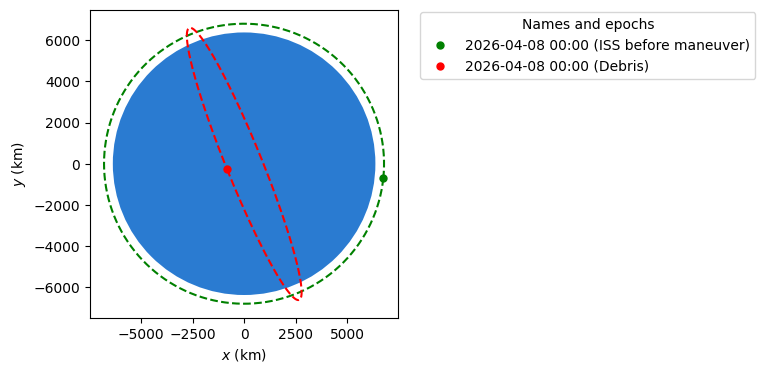

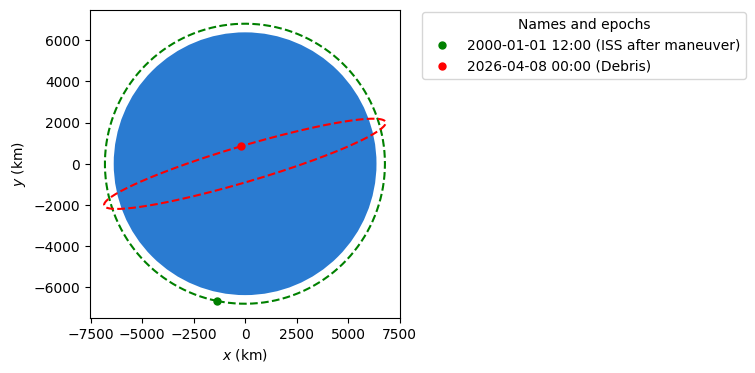

In [23]:
from poliastro.plotting.static import StaticOrbitPlotter
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4,4))
plotter = StaticOrbitPlotter(ax)

# before maneuver
plotter.plot(iss_orbit, label="ISS before maneuver",color="green")
plotter.plot(deb_orbit, label="Debris",color="red")
#plt.savefig("orbit_before_maneuver.pdf")

# after maneuver
fig2, ax2 = plt.subplots(figsize=(4,4))
plotter2 = StaticOrbitPlotter(ax2)
plotter2.plot(iss_new_orbit, label="ISS after maneuver",color="green")
plotter2.plot(deb_orbit, label="Debris",color="red")
#plt.savefig("orbit_after_maneuver.pdf")